# Обучение сверточной нейронной сети для классификации изображений.

* Основано на [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python-second-edition?gclid=CjwKCAjw9aiIBhA1EiwAJ_GTSlKgxc4qopKHPsFWryOoTz7fvhvhzYSjEsgQ-bG1R51QSGppISywpBoClcIQAvD_BwE) by Francois Chollett

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# инициализируйте начальные значения различных генераторов случайных чисел таким образом, чтобы
# Результаты будут одинаковыми при каждом запуске ноутбука.
keras.utils.set_random_seed(42)

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Давайте создадим небольшой список на Python, чтобы нам было проще преобразовывать числа в описания.

In [4]:
labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]

Чтобы свести к минимуму ввод текста, мы повторно используем функции из предыдущей версии Colab.

In [5]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Обучения потери")
  plt.plot(epochs, val_loss_values, "b", label="Потери валидации")
  plt.title("Потери обучения и валидации")
  plt.xlabel("Эпохи")
  plt.ylabel("Потери")
  plt.legend()
  plt.show()

In [6]:
def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Обучения acc")
  plt.plot(epochs, val_acc, "b", label="Валидации acc")
  plt.title("Аккуратность обучения и валидации")
  plt.xlabel("Эпохи")
  plt.ylabel("Аккуратность")
  plt.legend()
  plt.show()

## Сверточная нейронная сеть




### Сверточные слои



Мы будем следовать той же последовательности шагов, что и выше:


*   Подготовка данных
*   Определить модель
*   Задать параметры оптимизации
*   Обучить модель
*   Оценить модель


### Подготовка данных


Как и прежде, давайте нормализуем значения до диапазона 0-1, разделив все на 255.

In [7]:
x_train = x_train/ 255.0
x_test = x_test/ 255.0

In [8]:
x_train.shape

(60000, 28, 28)

По причинам, которые станут ясны позже при работе с цветными изображениями, нам также необходимо добавить еще одно измерение к каждому примеру, чтобы оно изменилось с 28x28 до 28x28x1.

In [9]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [10]:
x_train.shape

(60000, 28, 28, 1)

### Определить модель

Мы готовы создать нашу первую **сверточную нейронную сеть (CNN)!**


In [11]:
# входной слой
input = keras.Input(shape=x_train.shape[1:])

#
# первый сверточный блок
#
# сверточный слой
x = keras.layers.Conv2D(32,                    # Количество фильтров
                        kernel_size=(2, 2),    # Форма каждого фильтра
                        activation="relu",     # Активация RELU как обычно
                        name="Conv_1")(input)
# слой пулинга
x = keras.layers.MaxPool2D()(x)
# конец первого сверточного блока

#
# второй сверточный блок
#
# сверточный слой
x = keras.layers.Conv2D(32,                    # Количество фильтров
                        kernel_size=(2, 2),    # Форма каждого фильтра
                        activation="relu",     # Активация RELU как обычно
                        name="Conv_2")(x)
# слой пулинга
x = keras.layers.MaxPool2D()(x)
# конец второго сверточного блока

# выравнивающий слой
x = keras.layers.Flatten()(x)

# полносвязный (плотный) слой ReLU
x = keras.layers.Dense(256, activation="relu")(x)

# выходной слой softmax
output = keras.layers.Dense(10, activation="softmax")(x)


model = keras.Model(input, output)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 302,026 (1.15 MB)

 Trainable params: 302,026 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

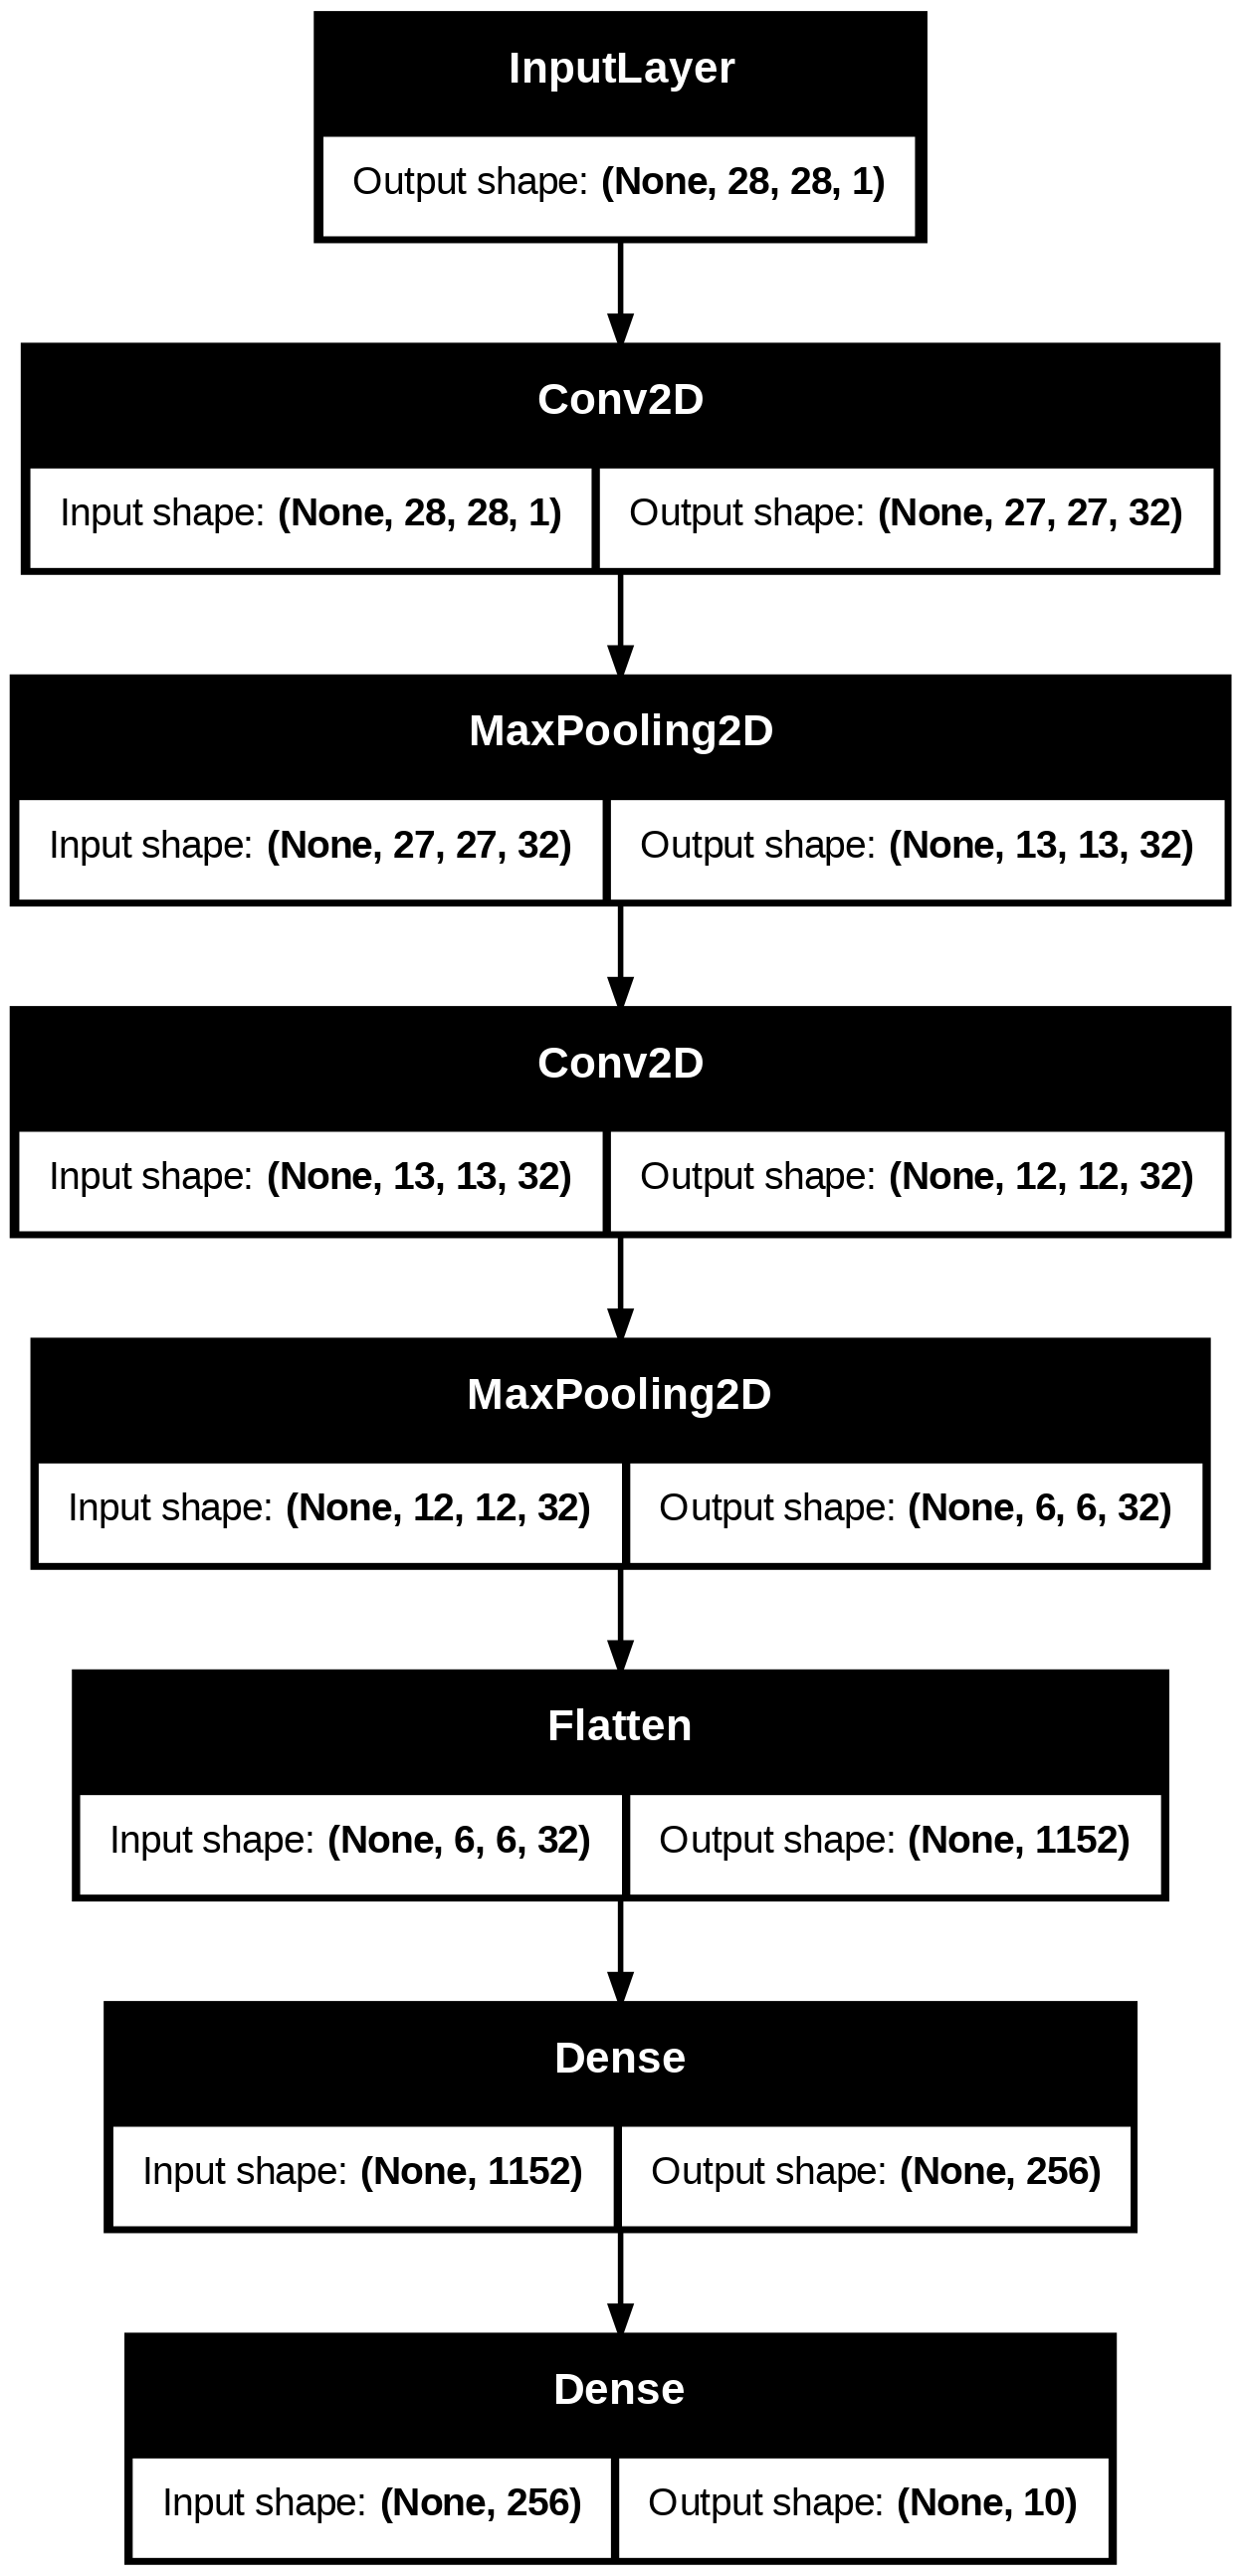

In [13]:
keras.utils.plot_model(model, show_shapes=True)

### Задать параметры оптимизации

Всё как и раньше ...

In [14]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

### Обучите модель

In [15]:
history = model.fit(x_train,
                    y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8163 - loss: 0.5088 - val_accuracy: 0.8698 - val_loss: 0.3696
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8784 - loss: 0.3399 - val_accuracy: 0.8875 - val_loss: 0.3105
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8940 - loss: 0.2908 - val_accuracy: 0.8948 - val_loss: 0.2839
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9053 - loss: 0.2587 - val_accuracy: 0.9018 - val_loss: 0.2653
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9143 - loss: 0.2334 - val_accuracy: 0.9036 - val_loss: 0.2581
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9210 - loss: 0.2127 - val_accuracy: 0.9059 - val_loss: 0.2542
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9285 - loss: 0.1931 - val_accuracy: 0.9082 - val_loss: 0.2557
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9352 - loss: 0.1756 - val_accuracy: 0.

Как обычно, давайте построим кривые потерь и точности.

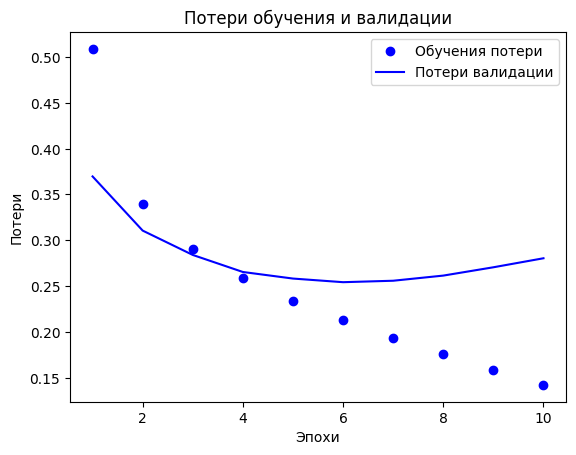

In [16]:
plot_loss_curves(history)

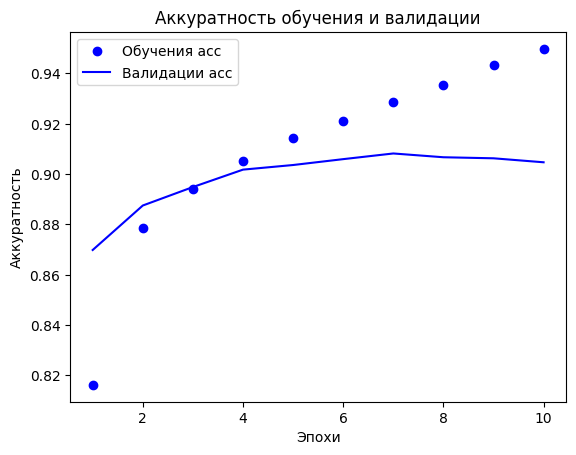

In [17]:
plot_acc_curves(history)

Показатели ошибок/точности при валидации выравниваются, но пока не увеличиваются, поэтому мы можем просто продолжить работу с этой моделью.

### Оцените модель

In [18]:
score = model.evaluate(x_test, y_test)
print("Test accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8989 - loss: 0.2936
Test accuracy: 0.8988999724388123


**Отлично! На тестовом наборе данных мы достигли точности более 90% — здорово.**




> Использование двух **специализированных слоев — сверточного и пулингового —** помогло нам превысить 90%.



Обратно к Fashion MNIST. Let's see what the **[state of the art (SOTA)](https://paperswithcode.com/sota/image-classification-on-fashion-mnist)** accuracy is.

It is **96.91%**!

<br>


**Задача: Можно ли достичь наивысшего результата, экспериментируя с архитектурой сети?** Добавить больше сверточных слоев, изменить размер каждого сверточного фильтра и т. д.



## Поэтапное улучшение модели

> **Практический совет**: После построения любой модели полезно проанализировать результаты на тестовом наборе данных и определить, для каких типов примеров модель испытывает трудности с прогнозированием. Это часто позволяет подсказать, как можно улучшить модель.

В задачах, где входные данные состоят из *изображений* (например, Fashion MNIST), **визуализация** может оказаться очень полезной.


In [20]:
# получить прогнозы
y_hat = np.argmax(model.predict(x_test), axis=1)

# Соберите примеры, в которых модель допустила ошибку.
misses = np.where(y_hat != y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


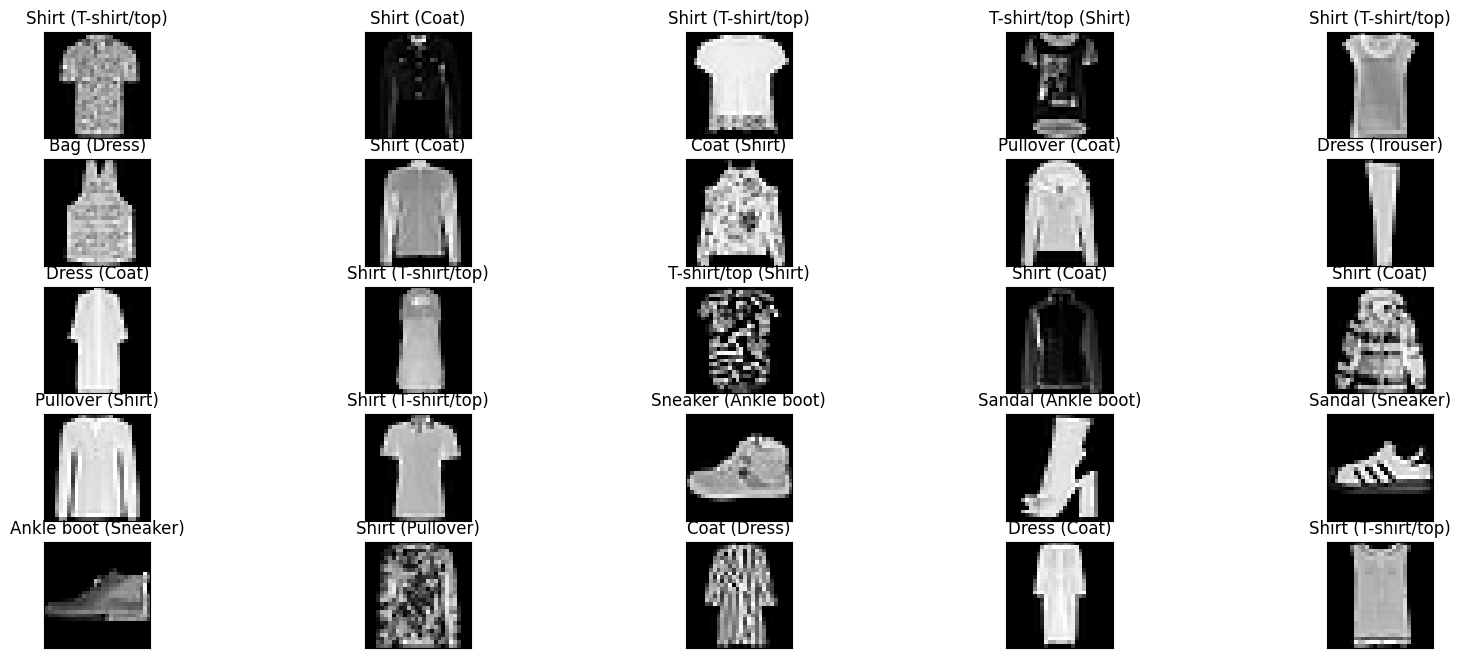

In [21]:
# Постройте график случайной выборки из 25 тестовых изображений, неправильно классифицированных моделью,
# их предсказанные ярлыки и реальные данные
figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(misses[0], size=25, replace=False)):
    ax = figure.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    # Отобразить каждое изображение
    ax.imshow(np.squeeze(x_test[index]), cmap="gray")
    # Задайте заголовок для каждого изображения.
    ax.set_title("{} ({})".format(labels[y_hat[index]],
                                  labels[y_test[index]]))

Как видите, модель, похоже, испытывает трудности с различением *визуально похожих* категорий.

**Матрица ошибок** — это хороший способ получить полную картину этого явления.

In [22]:
actuals = [labels[i] for i in y_test]
predictions = [labels[i] for i in y_hat]

In [23]:
df = pd.DataFrame({'Predictions': predictions, 'Actuals': actuals})
pd.crosstab(df.Predictions, df.Actuals)

Actuals,Ankle boot,Bag,Coat,Dress,Pullover,Sandal,Shirt,Sneaker,T-shirt/top,Trouser
Predictions,,,,,,,,,,
Ankle boot,940,0,0,0,0,2,0,16,1,0
Bag,0,971,0,1,0,0,3,0,5,0
Coat,0,4,789,19,34,0,48,0,2,4
Dress,0,5,26,906,6,0,20,0,16,21
Pullover,0,4,100,10,887,0,80,0,27,0
Sandal,12,2,0,0,0,995,0,20,2,0
Shirt,1,9,85,54,65,0,782,0,156,9
Sneaker,46,4,0,0,0,3,0,964,0,0
T-shirt/top,1,1,0,9,7,0,67,0,791,2


**Наблюдения**

*   Все числа, расположенные не по диагонали, обозначают ошибки, допущенные моделью.
*   Как видите, модель чаще всего ошибалась при выборе «рубашек». Она часто путала «рубашку» с «футболкой/топом». Это объяснимо, поскольку товары визуально похожи.



---
**Как можно улучшить модель?**

> **Совет**: Получите больше данных по тем категориям, которые модель с трудом различает (например, рубашки и футболки), обогатите исходный обучающий набор данных этими новыми примерами и переобучите модель.




## Заключение

Мы разработали модель глубокого обучения, которая может классифицировать изображения одежды в оттенках серого с точностью более 90%!

В следующем [next colab](https://colab.research.google.com/drive/18TNYD4_5a2PA3UTPOc4j2RNBFrofuk_T), мы будем обсуждать:
* Как работать с цветными изображениями
* Общая стратегия — **перенос обучения** — для решения задач на практике
* Примените общую стратегию для создания классификатора сумок/обуви всего со 100 примерами!

**DONE**

